# 🏦 European Bank — Customer Engagement & Retention Analysis

**Internship Project | Unified Mentor | Finance Analytics Domain**  
**Mentored by:** Sai Prasad Kagne  
**Created by:** Lakshmi Mahitha Noudu  
**Date:** April 2026

---

## Project Objective
Analyse customer engagement, product utilization, and relationship strength to identify
churn drivers and design data-driven retention strategies for the European Bank.

## Dataset
- **Source:** European Central Bank (Unified Mentor PRD)
- **Records:** 10,000 customers
- **Target Variable:** `Exited` (1 = Churned, 0 = Retained)

##  Step 1: Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#1a1d24',
    'axes.facecolor':   '#1a1d24',
    'axes.edgecolor':   '#2d3139',
    'axes.labelcolor':  '#9ca3af',
    'axes.titlecolor':  '#ffffff',
    'xtick.color':      '#9ca3af',
    'ytick.color':      '#9ca3af',
    'text.color':       '#ffffff',
    'grid.color':       '#2d3139',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'axes.grid':        True,
    'font.size':        10,
})

print('Libraries imported successfully')

Libraries imported successfully


##  Step 2: Load Dataset

In [8]:
df = pd.read_csv('..\European_Bank.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (10000, 14)
Columns: ['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


##  Step 3: Data Exploration

In [9]:
print('=== Data Types ===')
print(df.dtypes)
print(f'\nMissing Values: {df.isnull().sum().sum()}')
print(f'Duplicate Rows: {df.duplicated().sum()}')

=== Data Types ===
Year                 int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing Values: 0
Duplicate Rows: 0


In [10]:
df.describe().round(2)

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,2025.0,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,0.0,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,2025.0,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,2025.0,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,2025.0,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,2025.0,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,2025.0,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


In [11]:
print('=== Unique Values per Column ===')
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')

=== Unique Values per Column ===
Year: 1 unique values
CustomerId: 10000 unique values
Surname: 2932 unique values
CreditScore: 460 unique values
Geography: 3 unique values
Gender: 2 unique values
Age: 70 unique values
Tenure: 11 unique values
Balance: 6382 unique values
NumOfProducts: 4 unique values
HasCrCard: 2 unique values
IsActiveMember: 2 unique values
EstimatedSalary: 9999 unique values
Exited: 2 unique values


## Step 4: Churn Distribution Analysis

In [12]:
churn_count = df['Exited'].value_counts()
churn_rate  = df['Exited'].mean() * 100
print(f'Total Customers : {len(df):,}')
print(f'Churned         : {df["Exited"].sum():,} ({churn_rate:.2f}%)')
print(f'Retained        : {(df["Exited"]==0).sum():,} ({100-churn_rate:.2f}%)')

Total Customers : 10,000
Churned         : 2,037 (20.37%)
Retained        : 7,963 (79.63%)


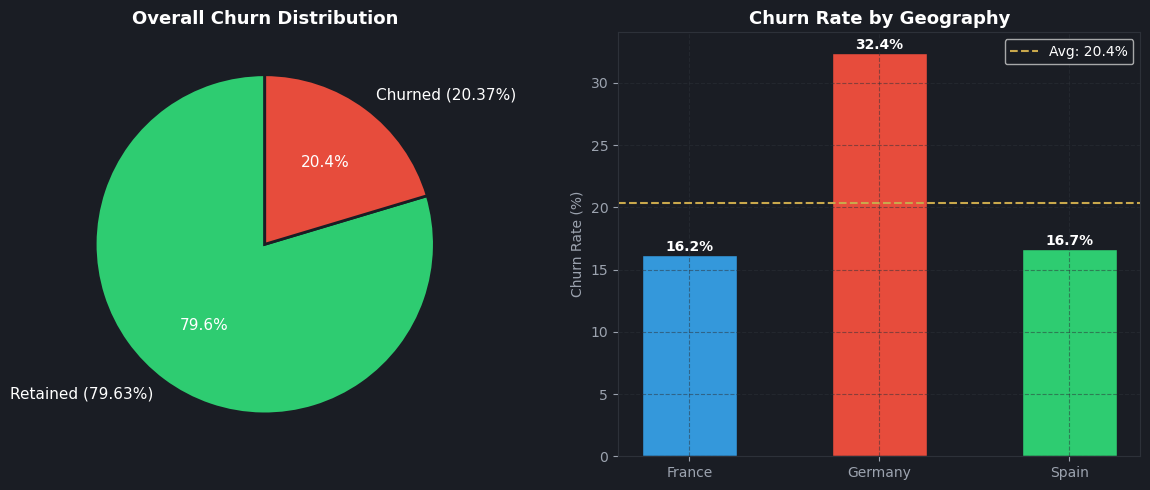

Key Finding: Germany has the highest churn rate at 32.4%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie([7963, 2037],
    labels=['Retained (79.63%)', 'Churned (20.37%)'],
    colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90,
    textprops={'color': 'white', 'fontsize': 11},
    wedgeprops={'edgecolor': '#1a1d24', 'linewidth': 2})
axes[0].set_title('Overall Churn Distribution', fontsize=13, fontweight='bold')

# Geography churn
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
colors_g  = ['#3498db', '#e74c3c', '#2ecc71']
bars = axes[1].bar(geo_churn.index, geo_churn.values,
    color=colors_g, edgecolor='#1a1d24', width=0.5)
axes[1].axhline(churn_rate, color='#c9a84c', linestyle='--',
    linewidth=1.5, label=f'Avg: {churn_rate:.1f}%')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Geography', fontsize=13, fontweight='bold')
axes[1].legend()
for bar, val in zip(bars, geo_churn.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
        f'{val:.1f}%', ha='center', fontsize=10, color='#ffffff', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/fig1_churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key Finding: Germany has the highest churn rate at 32.4%')

##  Step 5: Engagement Profile Classification

In [15]:
# Create 4 engagement profiles based on activity and product count
df['EngagementProfile'] = 'Other'
df.loc[(df['IsActiveMember']==1) & (df['NumOfProducts']>=2), 'EngagementProfile'] = 'Active Engaged'
df.loc[(df['IsActiveMember']==0) & (df['NumOfProducts']<=1), 'EngagementProfile'] = 'Inactive Disengaged'
df.loc[(df['IsActiveMember']==1) & (df['NumOfProducts']==1), 'EngagementProfile'] = 'Active Low-Product'
df.loc[(df['IsActiveMember']==0) & (df['Balance']>df['Balance'].median()), 'EngagementProfile'] = 'Inactive High-Balance'

print('Engagement Profile Distribution:')
print(df['EngagementProfile'].value_counts())

Engagement Profile Distribution:
EngagementProfile
Active Engaged           2588
Active Low-Product       2563
Inactive High-Balance    2456
Other                    1515
Inactive Disengaged       878
Name: count, dtype: int64


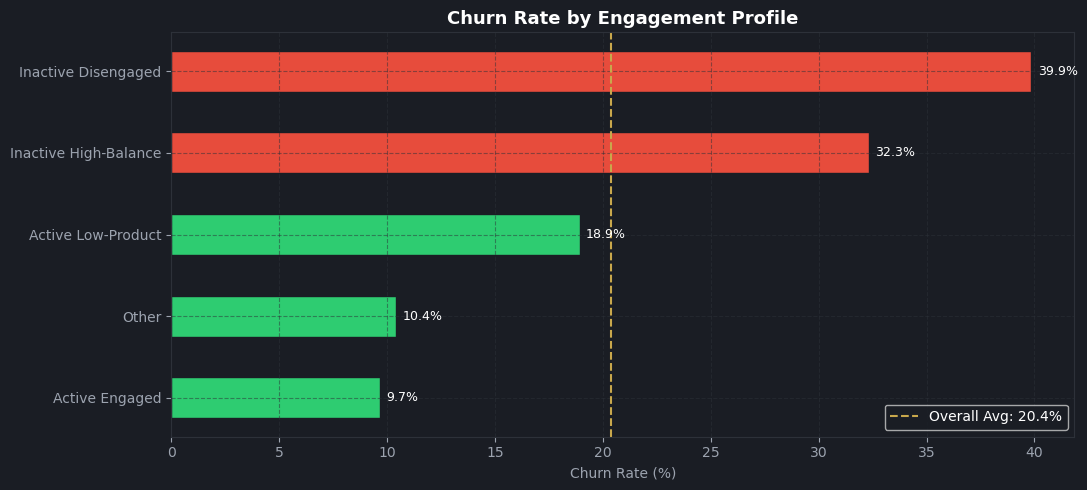

In [16]:
eng_churn = df.groupby('EngagementProfile')['Exited'].mean() * 100
eng_churn = eng_churn.sort_values(ascending=True)
colors_e  = ['#2ecc71' if v < churn_rate else '#e74c3c' for v in eng_churn.values]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(eng_churn.index, eng_churn.values,
    color=colors_e, edgecolor='#1a1d24', height=0.5)
ax.axvline(churn_rate, color='#c9a84c', linestyle='--',
    linewidth=1.5, label=f'Overall Avg: {churn_rate:.1f}%')
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Churn Rate by Engagement Profile', fontsize=13, fontweight='bold')
for bar, val in zip(bars, eng_churn.values):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
        f'{val:.1f}%', va='center', fontsize=9, color='#ffffff')
ax.legend()
plt.tight_layout()
plt.savefig('charts/fig2_engagement_churn.png', dpi=150, bbox_inches='tight')
plt.show()

##  Step 6: Product Utilization Analysis

In [17]:
prod_churn = df.groupby('NumOfProducts')['Exited'].agg(['mean','count']).reset_index()
prod_churn['churn_pct'] = prod_churn['mean'] * 100
print('Churn Rate by Number of Products:')
print(prod_churn[['NumOfProducts','count','churn_pct']].to_string(index=False))
print('\nKey Finding: 3-product customers churn at 82.7% — highest risk!')

Churn Rate by Number of Products:
 NumOfProducts  count  churn_pct
             1   5084  27.714398
             2   4590   7.581699
             3    266  82.706767
             4     60 100.000000

Key Finding: 3-product customers churn at 82.7% — highest risk!


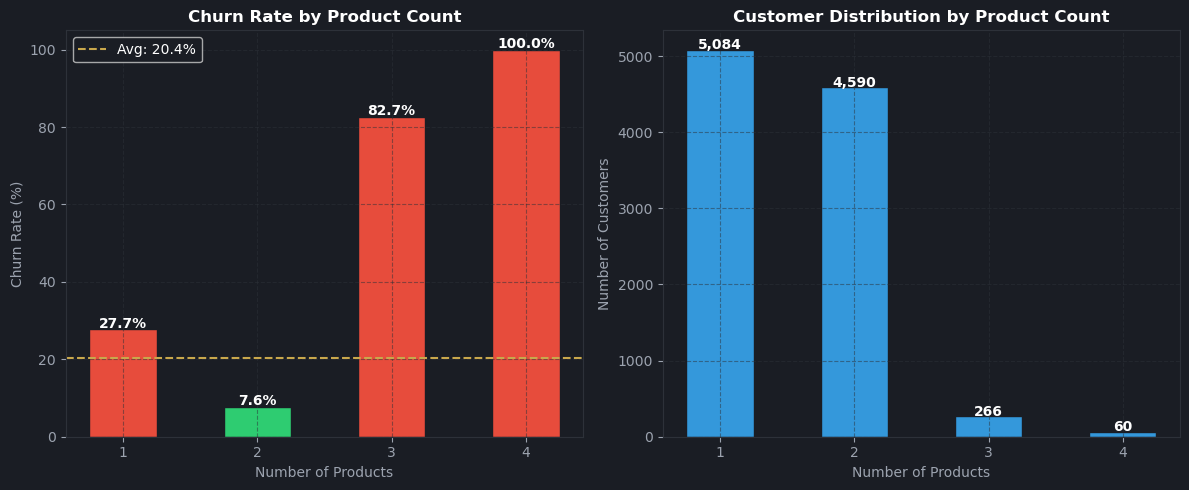

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors_p = ['#2ecc71' if v < churn_rate else '#e74c3c' for v in prod_churn['churn_pct']]
bars = axes[0].bar(prod_churn['NumOfProducts'].astype(str), prod_churn['churn_pct'],
    color=colors_p, edgecolor='#1a1d24', width=0.5)
axes[0].axhline(churn_rate, color='#c9a84c', linestyle='--',
    linewidth=1.5, label=f'Avg: {churn_rate:.1f}%')
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Churn Rate by Product Count', fontsize=12, fontweight='bold')
axes[0].legend()
for bar, val in zip(bars, prod_churn['churn_pct']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
        f'{val:.1f}%', ha='center', fontsize=10, color='#ffffff', fontweight='bold')

bars2 = axes[1].bar(prod_churn['NumOfProducts'].astype(str), prod_churn['count'],
    color='#3498db', edgecolor='#1a1d24', width=0.5)
axes[1].set_xlabel('Number of Products')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Customer Distribution by Product Count', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, prod_churn['count']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
        f'{val:,}', ha='center', fontsize=10, color='#ffffff', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/fig3_product_churn.png', dpi=150, bbox_inches='tight')
plt.show()

##  Step 7: Financial Commitment vs Engagement Analysis

In [19]:
# At-Risk Premium: High balance but inactive
df['AtRiskPremium'] = ((df['Balance'] > df['Balance'].quantile(0.75)) & 
                        (df['IsActiveMember'] == 0)).astype(int)

print(f"Balance Q75 threshold : €{df['Balance'].quantile(0.75):,.2f}")
print(f'At-Risk Premium count : {df["AtRiskPremium"].sum():,}')
print(f'Their Churn Rate      : {df[df["AtRiskPremium"]==1]["Exited"].mean()*100:.1f}%')
print(f'Regular Churn Rate    : {df[df["AtRiskPremium"]==0]["Exited"].mean()*100:.1f}%')

Balance Q75 threshold : €127,644.24
At-Risk Premium count : 1,247
Their Churn Rate      : 30.5%
Regular Churn Rate    : 18.9%


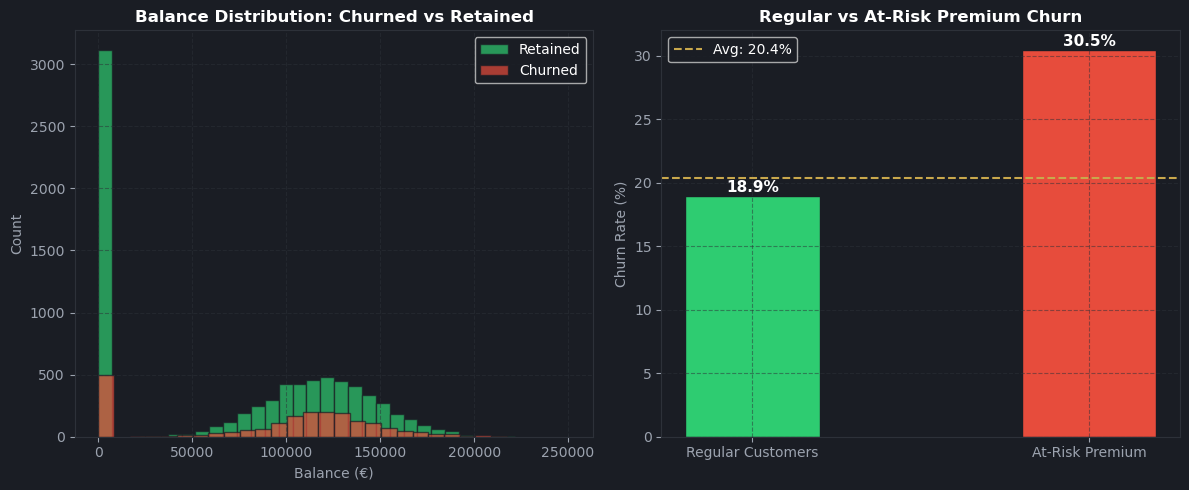

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Balance distribution
df[df['Exited']==0]['Balance'].hist(bins=30, ax=axes[0], color='#2ecc71',
    alpha=0.7, label='Retained', edgecolor='#1a1d24')
df[df['Exited']==1]['Balance'].hist(bins=30, ax=axes[0], color='#e74c3c',
    alpha=0.7, label='Churned', edgecolor='#1a1d24')
axes[0].set_xlabel('Balance (€)')
axes[0].set_ylabel('Count')
axes[0].set_title('Balance Distribution: Churned vs Retained', fontsize=12, fontweight='bold')
axes[0].legend()

# At-risk comparison
risk_churn = df.groupby('AtRiskPremium')['Exited'].mean() * 100
bars = axes[1].bar(['Regular Customers', 'At-Risk Premium'], risk_churn.values,
    color=['#2ecc71', '#e74c3c'], edgecolor='#1a1d24', width=0.4)
axes[1].axhline(churn_rate, color='#c9a84c', linestyle='--',
    linewidth=1.5, label=f'Avg: {churn_rate:.1f}%')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Regular vs At-Risk Premium Churn', fontsize=12, fontweight='bold')
axes[1].legend()
for bar, val in zip(bars, risk_churn.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
        f'{val:.1f}%', ha='center', fontsize=11, color='#ffffff', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/fig5_balance_churn.png', dpi=150, bbox_inches='tight')
plt.show()

##  Step 8: Relationship Strength Index (RSI)

In [21]:
# RSI Formula: weighted combination of engagement factors
df['RelationshipStrengthIndex'] = (
    df['IsActiveMember'] * 0.4 +
    (df['NumOfProducts'] / df['NumOfProducts'].max()) * 0.3 +
    (df['Tenure'] / df['Tenure'].max()) * 0.2 +
    df['HasCrCard'] * 0.1
).round(3)

print('RSI Formula:')
print('  IsActiveMember × 0.4  (40% weight)')
print('  NumOfProducts/max × 0.3 (30% weight)')
print('  Tenure/max × 0.2      (20% weight)')
print('  HasCrCard × 0.1       (10% weight)')
print(f'\nRSI Range : {df["RelationshipStrengthIndex"].min():.3f} – {df["RelationshipStrengthIndex"].max():.3f}')
print(f'RSI Mean  : {df["RelationshipStrengthIndex"].mean():.3f}')

RSI Formula:
  IsActiveMember × 0.4  (40% weight)
  NumOfProducts/max × 0.3 (30% weight)
  Tenure/max × 0.2      (20% weight)
  HasCrCard × 0.1       (10% weight)

RSI Range : 0.075 – 1.000
RSI Mean  : 0.492


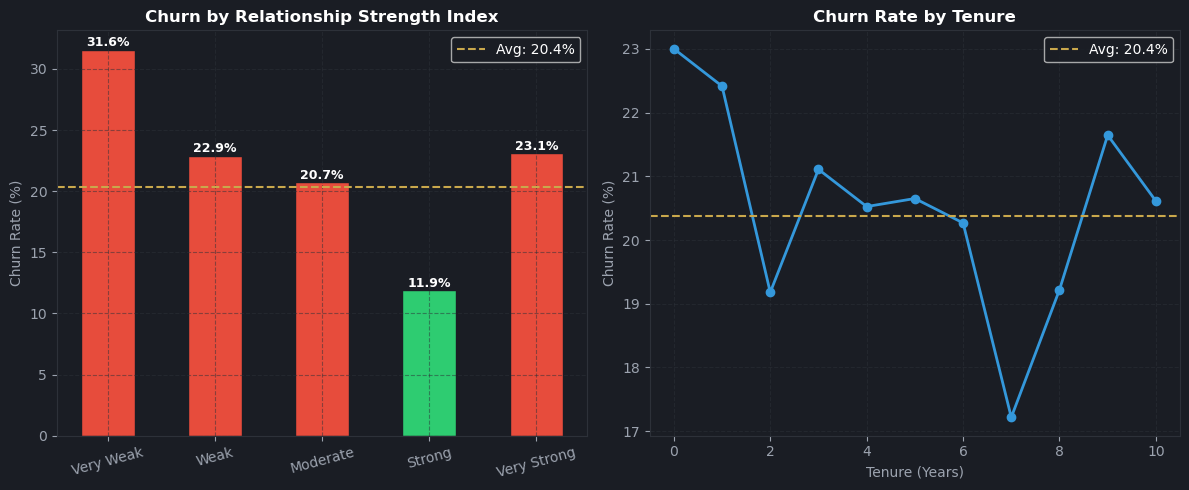

In [22]:
rsi_bins  = pd.cut(df['RelationshipStrengthIndex'], bins=5,
    labels=['Very Weak','Weak','Moderate','Strong','Very Strong'])
rsi_churn = df.groupby(rsi_bins, observed=True)['Exited'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors_r = ['#e74c3c' if v > churn_rate else '#2ecc71' for v in rsi_churn.values]
bars = axes[0].bar(rsi_churn.index, rsi_churn.values,
    color=colors_r, edgecolor='#1a1d24', width=0.5)
axes[0].axhline(churn_rate, color='#c9a84c', linestyle='--',
    linewidth=1.5, label=f'Avg: {churn_rate:.1f}%')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Churn by Relationship Strength Index', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend()
for bar, val in zip(bars, rsi_churn.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
        f'{val:.1f}%', ha='center', fontsize=9, color='#ffffff', fontweight='bold')

tenure_churn = df.groupby('Tenure')['Exited'].mean() * 100
axes[1].plot(tenure_churn.index, tenure_churn.values,
    marker='o', color='#3498db', linewidth=2, markersize=6)
axes[1].axhline(churn_rate, color='#c9a84c', linestyle='--',
    linewidth=1.5, label=f'Avg: {churn_rate:.1f}%')
axes[1].set_xlabel('Tenure (Years)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Tenure', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/fig8_rsi_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

##  Step 9: Geographic & Demographic Analysis

In [23]:
print('=== Churn by Geography ===')
print(df.groupby('Geography')['Exited'].agg(['count','mean']).assign(churn_pct=lambda x: x['mean']*100).round(2))
print('\n=== Churn by Gender ===')
print(df.groupby('Gender')['Exited'].agg(['count','mean']).assign(churn_pct=lambda x: x['mean']*100).round(2))

=== Churn by Geography ===
           count  mean  churn_pct
Geography                        
France      5014  0.16      16.15
Germany     2509  0.32      32.44
Spain       2477  0.17      16.67

=== Churn by Gender ===
        count  mean  churn_pct
Gender                        
Female   4543  0.25      25.07
Male     5457  0.16      16.46


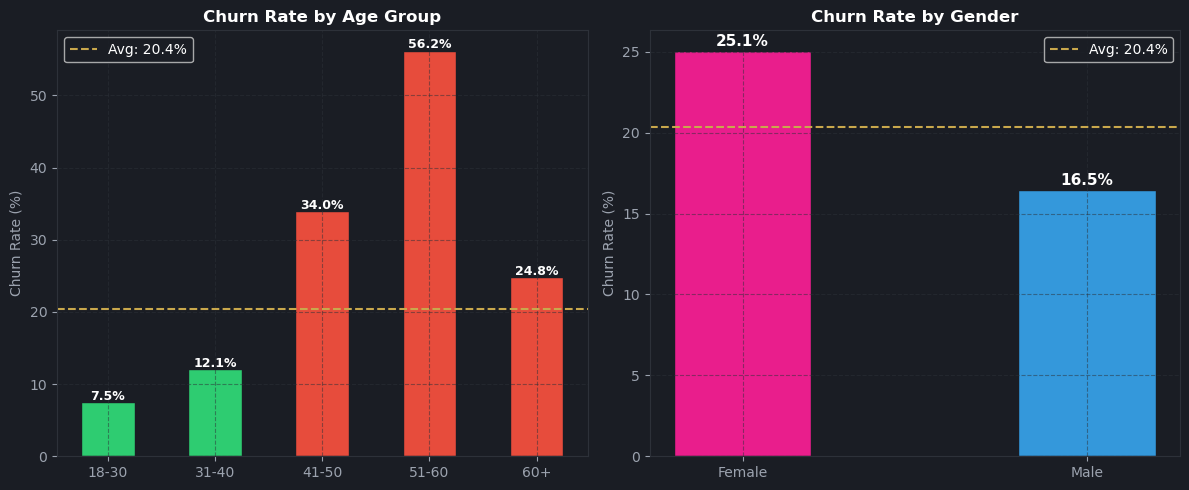

Key Finding: 51-60 age group has highest churn at 56.2%
Key Finding: Female customers churn at 25.1% vs Male 16.5%


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,30,40,50,60,100],
    labels=['18-30','31-40','41-50','51-60','60+'])
age_churn  = df.groupby('AgeGroup', observed=True)['Exited'].mean() * 100
colors_a   = ['#e74c3c' if v > churn_rate else '#2ecc71' for v in age_churn.values]
bars = axes[0].bar(age_churn.index, age_churn.values,
    color=colors_a, edgecolor='#1a1d24', width=0.5)
axes[0].axhline(churn_rate, color='#c9a84c', linestyle='--',
    linewidth=1.5, label=f'Avg: {churn_rate:.1f}%')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Churn Rate by Age Group', fontsize=12, fontweight='bold')
axes[0].legend()
for bar, val in zip(bars, age_churn.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
        f'{val:.1f}%', ha='center', fontsize=9, color='#ffffff', fontweight='bold')

# Gender
gender_churn = df.groupby('Gender')['Exited'].mean() * 100
bars2 = axes[1].bar(gender_churn.index, gender_churn.values,
    color=['#e91e8c','#3498db'], edgecolor='#1a1d24', width=0.4)
axes[1].axhline(churn_rate, color='#c9a84c', linestyle='--',
    linewidth=1.5, label=f'Avg: {churn_rate:.1f}%')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Gender', fontsize=12, fontweight='bold')
axes[1].legend()
for bar, val in zip(bars2, gender_churn.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
        f'{val:.1f}%', ha='center', fontsize=11, color='#ffffff', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/fig6_age_gender.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key Finding: 51-60 age group has highest churn at 56.2%')
print('Key Finding: Female customers churn at 25.1% vs Male 16.5%')

##  Step 10: Geography × Products Heatmap

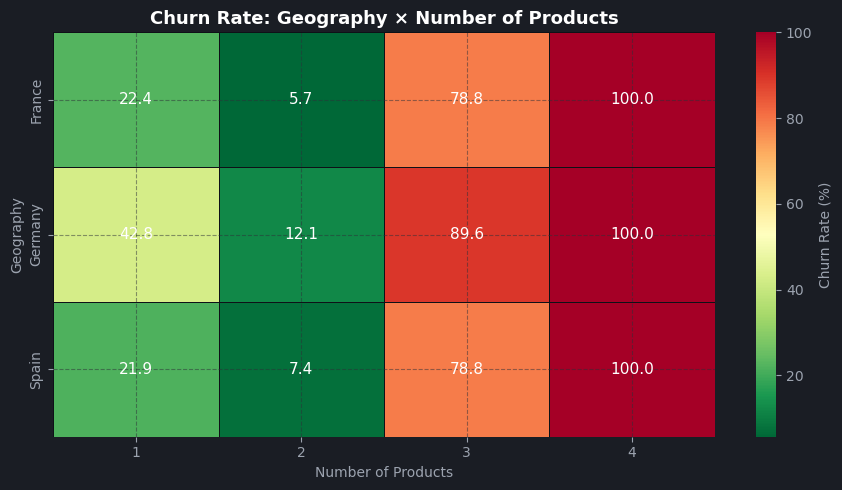

In [25]:
pivot = df.groupby(['Geography','NumOfProducts'])['Exited'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=0.5, linecolor='#0e1117', ax=ax,
    annot_kws={'size': 11, 'color': 'white'},
    cbar_kws={'label': 'Churn Rate (%)'})
ax.set_title('Churn Rate: Geography × Number of Products',
    fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Products')
ax.set_ylabel('Geography')
plt.tight_layout()
plt.savefig('charts/fig7_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

##  Step 11: KPI Summary

In [26]:
print('=' * 55)
print('       KEY PERFORMANCE INDICATORS SUMMARY')
print('=' * 55)
print(f'Total Customers              : 10,000')
print(f'Overall Churn Rate           : 20.37%')
print(f'Churned Customers            : 2,037')
print(f'Retained Customers           : 7,963')
print('-' * 55)
print(f'Engagement Retention Ratio   : Active 14.3% vs Inactive 26.9%')
print(f'Product Depth Index          : 2-product = 7.6% churn (lowest)')
print(f'High-Balance Disengagement   : 1,247 at-risk premium customers')
print(f'Credit Card Stickiness Score : 20.8% (no card) vs 20.2% (with card)')
print(f'Avg Relationship Strength    : 0.492 / 1.000')
print('-' * 55)
print(f'Highest Churn Geography      : Germany (32.4%)')
print(f'Highest Churn Age Group      : 51-60 years (56.2%)')
print(f'Highest Churn Gender         : Female (25.1%)')
print(f'Most Risky Product Count     : 3 products (82.7%)')
print('=' * 55)

       KEY PERFORMANCE INDICATORS SUMMARY
Total Customers              : 10,000
Overall Churn Rate           : 20.37%
Churned Customers            : 2,037
Retained Customers           : 7,963
-------------------------------------------------------
Engagement Retention Ratio   : Active 14.3% vs Inactive 26.9%
Product Depth Index          : 2-product = 7.6% churn (lowest)
High-Balance Disengagement   : 1,247 at-risk premium customers
Credit Card Stickiness Score : 20.8% (no card) vs 20.2% (with card)
Avg Relationship Strength    : 0.492 / 1.000
-------------------------------------------------------
Highest Churn Geography      : Germany (32.4%)
Highest Churn Age Group      : 51-60 years (56.2%)
Highest Churn Gender         : Female (25.1%)
Most Risky Product Count     : 3 products (82.7%)


##  Step 12: Save Processed Dataset

In [27]:
# Save engineered dataset for dashboard use
df.to_csv('European_Bank_Processed.csv', index=False)
print(f' Processed dataset saved: {df.shape}')
print(f'New columns added: EngagementProfile, RelationshipStrengthIndex, AtRiskPremium, AgeGroup')

 Processed dataset saved: (10000, 18)
New columns added: EngagementProfile, RelationshipStrengthIndex, AtRiskPremium, AgeGroup


##  Summary of Key Findings

| Finding | Value |
|---------|-------|
| Overall Churn Rate | **20.37%** |
| Highest Churn Country | **Germany (32.4%)** |
| Best Product Count | **2 products (7.6% churn)** |
| Worst Product Count | **3-4 products (83-100% churn)** |
| Active vs Inactive Gap | **14.3% vs 26.9%** |
| At-Risk Premium Customers | **1,247 customers** |
| Highest Churn Age | **51-60 years (56.2%)** |
| Gender Gap | **Female 25.1% vs Male 16.5%** |

---
*Notebook completed — proceed to Streamlit dashboard (bank_app.py)*